# LibreOffice (soffice) PDF→DOCX Benchmark

**Purpose:** Evaluate whether LibreOffice's headless PDF→DOCX conversion can handle 60-page PDFs within the 90-second Celery task timeout.

**Approach:** LibreOffice uses its own rendering engine — no Python PDF parsing libraries at all. The entire conversion is a single subprocess call:
```bash
soffice --headless --convert-to docx --outdir <dir> <file.pdf>
```

**Key advantages over Python libraries:**
- Mature PDF import + DOCX export (same engine as the desktop app)
- Tables, images, fonts, layout — all handled natively
- No Python dependency chain (pdfminer, pdfplumber, etc.)
- Single binary, MPL-2.0 licensed

**Key concerns:**
- Requires LibreOffice installed (200+ MB)
- Subprocess overhead + process startup time
- No fine-grained control over conversion settings from Python
- Headless mode can occasionally hang on malformed PDFs

**Test PDFs generated with:** PyMuPDF (fitz) for scenarios 1-4, reportlab for scenario 5 (two-column MSA)

---

In [1]:
import fitz  # PyMuPDF — ONLY for generating test PDFs
import os
import struct
import subprocess
import time
import zipfile
import zlib
from difflib import SequenceMatcher
from xml.etree import ElementTree as ET

from docx import Document

PAGES = 60
OUTPUT_DIR = "/tmp/libreoffice_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

# Check LibreOffice version
version = subprocess.check_output(["soffice", "--version"], text=True).strip()
print(f"LibreOffice version: {version}")
print(f"PyMuPDF version (test PDF generation only): {fitz.version}")
print(f"Output directory: {OUTPUT_DIR}/")
print(f"Generating {PAGES}-page test PDFs...")


def extract_all_text_from_docx(docx_path):
    """Extract text from DOCX including text boxes and drawing objects.
    
    LibreOffice wraps text in drawing objects/text frames rather than
    direct paragraphs, so we parse the DOCX XML directly to find ALL
    text runs including those inside <w:txbxContent> and
    <mc:AlternateContent> elements.
    """
    with zipfile.ZipFile(docx_path) as z:
        with z.open('word/document.xml') as f:
            tree = ET.parse(f)
    ns = {'w': 'http://schemas.openxmlformats.org/wordprocessingml/2006/main'}
    texts = []
    for t_elem in tree.iter('{http://schemas.openxmlformats.org/wordprocessingml/2006/main}t'):
        if t_elem.text:
            texts.append(t_elem.text)
    return " ".join(texts)


def compute_similarity(ground_truth: str, extracted_text: str) -> dict:
    """Compute text similarity metrics between ground truth and extracted text."""
    gt_clean = " ".join(ground_truth.split())
    ext_clean = " ".join(extracted_text.split())
    gt_sample = gt_clean[:50000]
    ext_sample = ext_clean[:50000]
    seq_ratio = SequenceMatcher(None, gt_sample, ext_sample).ratio()
    gt_words = set(gt_clean.lower().split())
    ext_words = set(ext_clean.lower().split())
    word_recall = len(gt_words & ext_words) / len(gt_words) if gt_words else 1.0
    char_ratio = len(ext_clean) / len(gt_clean) if len(gt_clean) > 0 else 1.0
    return {"seq_ratio": seq_ratio, "word_recall": word_recall, "char_ratio": char_ratio}


def convert_with_libreoffice(pdf_path, output_dir):
    """Convert PDF to DOCX using LibreOffice headless mode.
    
    Key: --infilter="writer_pdf_import" forces LibreOffice to open the PDF
    as a Writer document (not Draw), which enables DOCX export.
    
    Returns the path to the generated DOCX file.
    """
    result = subprocess.run(
        [
            "soffice", "--headless",
            '--infilter=writer_pdf_import',
            "--convert-to", "docx",
            "--outdir", output_dir,
            pdf_path,
        ],
        capture_output=True, text=True, timeout=300,
    )
    if result.returncode != 0:
        print(f"  ERROR: {result.stderr}")
    if result.stdout:
        print(f"  soffice: {result.stdout.strip()}")
    # soffice outputs to same name with .docx extension
    base = os.path.splitext(os.path.basename(pdf_path))[0]
    return os.path.join(output_dir, base + ".docx")


def run_benchmark(name, pdf_path, ground_truth_text=""):
    """Convert a PDF to DOCX using LibreOffice and record timing + similarity."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    
    start = time.time()
    docx_path = convert_with_libreoffice(pdf_path, OUTPUT_DIR)
    elapsed = time.time() - start
    
    if not os.path.exists(docx_path):
        print(f"  FAILED: DOCX not generated")
        results.append({
            "scenario": name, "pdf_kb": pdf_kb, "docx_kb": 0,
            "total_s": elapsed, "per_page_s": elapsed / PAGES,
            "verdict": "FAILED", "paras": 0, "tables": 0, "cells": 0, "images": 0,
            "seq_ratio": 0.0, "word_recall": 0.0, "char_ratio": 0.0,
        })
        return elapsed
    
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    
    # Quality check: count paragraphs, tables, cells, images
    doc_check = Document(docx_path)
    n_paras = len([p for p in doc_check.paragraphs if p.text.strip()])
    n_tables = len(doc_check.tables)
    n_cells = sum(len(r.cells) for t in doc_check.tables for r in t.rows)
    with zipfile.ZipFile(docx_path) as z:
        n_images = len([n for n in z.namelist() if n.startswith("word/media/")])
    
    # Text similarity metrics
    sim = {"seq_ratio": 0.0, "word_recall": 0.0, "char_ratio": 0.0}
    if ground_truth_text:
        extracted_text = extract_all_text_from_docx(docx_path)
        sim = compute_similarity(ground_truth_text, extracted_text)
        print(f"  Similarity:  seq_ratio={sim['seq_ratio']:.3f}, word_recall={sim['word_recall']:.3f}, char_ratio={sim['char_ratio']:.3f}")
    
    results.append({
        "scenario": name, "pdf_kb": pdf_kb, "docx_kb": docx_kb,
        "total_s": elapsed, "per_page_s": per_page, "verdict": verdict,
        "paras": n_paras, "tables": n_tables, "cells": n_cells, "images": n_images,
        "seq_ratio": sim["seq_ratio"], "word_recall": sim["word_recall"], "char_ratio": sim["char_ratio"],
    })
    
    print(f"  PDF size:    {pdf_kb:,.0f} KB  →  {pdf_path}")
    print(f"  DOCX size:   {docx_kb:,.0f} KB  →  {docx_path}")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    print(f"  Quality:     {n_paras} paragraphs, {n_tables} tables, {n_cells} cells, {n_images} images")
    return elapsed

LibreOffice version: LibreOffice 25.8.2.2 d401f2107ccab8f924a8e2df40f573aab7605b6f
PyMuPDF version (test PDF generation only): ('1.24.3', '1.24.2', '20240509000001')
Output directory: /tmp/libreoffice_bench/
Generating 60-page test PDFs...


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

**Best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "text_only.pdf")

gt_lines = []
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    heading = f"Page {i+1} - Document Title"
    page.insert_text((72, 72), heading, fontsize=18, fontname="helv")
    gt_lines.append(heading)
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        text = line[:90]
        page.insert_text((72, y), text, fontsize=10, fontname="helv")
        gt_lines.append(text)
        y += 20
doc.save(pdf_path)
doc.close()

gt_text = "\n".join(gt_lines)

print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_benchmark("Text-only", pdf_path, ground_truth_text=gt_text)

Scenario 1: Text-Only (25 lines/page)


  soffice: convert /tmp/libreoffice_bench/text_only.pdf as a Writer document -> /private/tmp/libreoffice_bench/text_only.docx using filter : Office Open XML Text
Overwriting: /private/tmp/libreoffice_bench/text_only.docx


  Similarity:  seq_ratio=0.500, word_recall=1.000, char_ratio=2.000
  PDF size:    398 KB  →  /tmp/libreoffice_bench/text_only.pdf
  DOCX size:   72 KB  →  /tmp/libreoffice_bench/text_only.docx
  Total time:  2.77s
  Per page:    0.046s
  Verdict:     Safe
  Quality:     0 paragraphs, 0 tables, 0 cells, 0 images


2.7728209495544434

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5x4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "simple_tables.pdf")

gt_lines = []
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    heading = f"Section {i+1}: Analysis Report"
    page.insert_text((72, 60), heading, fontsize=16, fontname="helv")
    gt_lines.append(heading)
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        text = text[:95]
        page.insert_text((72, y), text, fontsize=10, fontname="helv")
        gt_lines.append(text)
        y += 18
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            cell_text = f"Cell {row},{col}: data"
            page.insert_text(
                (x0 + 5, y0 + 17), cell_text, fontsize=8, fontname="helv"
            )
            gt_lines.append(cell_text)
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        text = text[:95]
        page.insert_text((72, y), text, fontsize=10, fontname="helv")
        gt_lines.append(text)
        y += 18
doc.save(pdf_path)
doc.close()

gt_text = "\n".join(gt_lines)

print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_benchmark("Text + simple tables", pdf_path, ground_truth_text=gt_text)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  soffice: convert /tmp/libreoffice_bench/simple_tables.pdf as a Writer document -> /private/tmp/libreoffice_bench/simple_tables.docx using filter : Office Open XML Text
Overwriting: /private/tmp/libreoffice_bench/simple_tables.docx


  Similarity:  seq_ratio=0.420, word_recall=1.000, char_ratio=2.000
  PDF size:    593 KB  →  /tmp/libreoffice_bench/simple_tables.pdf
  DOCX size:   136 KB  →  /tmp/libreoffice_bench/simple_tables.docx
  Total time:  2.63s
  Per page:    0.044s
  Verdict:     Safe
  Quality:     0 paragraphs, 0 tables, 0 cells, 0 images


2.625257968902588

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. This was the **primary bottleneck** for pdf2docx (92-98s, exceeded 90s timeout).

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "dense_tables.pdf")

gt_lines = []
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    heading = f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT"
    page.insert_text(
        (72, 50), heading, fontsize=14, fontname="helv"
    )
    gt_lines.append(heading)
    subheading = "Confidential - Internal Use Only"
    page.insert_text((72, 70), subheading, fontsize=8, fontname="helv")
    gt_lines.append(subheading)
    for t in range(3):
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    cell_text = f"Header {col+1}"
                    page.insert_text(
                        (x0 + 3, y0 + 17), cell_text, fontsize=7, fontname="helv"
                    )
                else:
                    cell_text = f"{(i * 1000 + row * 100 + col * 10):,.2f}"
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        cell_text,
                        fontsize=7,
                        fontname="helv",
                    )
                gt_lines.append(cell_text)
doc.save(pdf_path)
doc.close()

gt_text = "\n".join(gt_lines)

print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_benchmark("Dense tables (worst case)", pdf_path, ground_truth_text=gt_text)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640



  soffice: convert /tmp/libreoffice_bench/dense_tables.pdf as a Writer document -> /private/tmp/libreoffice_bench/dense_tables.docx using filter : Office Open XML Text
Overwriting: /private/tmp/libreoffice_bench/dense_tables.docx


  Similarity:  seq_ratio=0.046, word_recall=1.000, char_ratio=2.000
  PDF size:    2,301 KB  →  /tmp/libreoffice_bench/dense_tables.pdf
  DOCX size:   454 KB  →  /tmp/libreoffice_bench/dense_tables.docx
  Total time:  13.92s
  Per page:    0.232s
  Verdict:     Safe
  Quality:     0 paragraphs, 0 tables, 0 cells, 0 images


13.920178890228271

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.**

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "mixed_content.pdf")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

gt_lines = []
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    heading = f"Document Section {i+1}"
    page.insert_text((72, 50), heading, fontsize=16, fontname="helv")
    gt_lines.append(heading)
    y = 80
    for j in range(5):
        text = f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs."
        page.insert_text(
            (72, y),
            text,
            fontsize=10,
            fontname="helv",
        )
        gt_lines.append(text)
        y += 16
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            cell_text = f"Val {row}{col}"
            page.insert_text((x0 + 3, y0 + 15), cell_text, fontsize=7, fontname="helv")
            gt_lines.append(cell_text)
    y2 = table_y + 160
    for j in range(6):
        text = f"Conclusion line {j+1}: Based on the above data we recommend proceeding."
        page.insert_text(
            (72, y2),
            text,
            fontsize=10,
            fontname="helv",
        )
        gt_lines.append(text)
        y2 += 16
doc.save(pdf_path)
doc.close()

gt_text = "\n".join(gt_lines)

print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_benchmark("Mixed content", pdf_path, ground_truth_text=gt_text)

Scenario 4: Mixed Content (text + images + tables)


  soffice: convert /tmp/libreoffice_bench/mixed_content.pdf as a Writer document -> /private/tmp/libreoffice_bench/mixed_content.docx using filter : Office Open XML Text
Overwriting: /private/tmp/libreoffice_bench/mixed_content.docx


  Similarity:  seq_ratio=0.403, word_recall=1.000, char_ratio=2.000
  PDF size:    730 KB  →  /tmp/libreoffice_bench/mixed_content.pdf
  DOCX size:   159 KB  →  /tmp/libreoffice_bench/mixed_content.docx
  Total time:  5.06s
  Per page:    0.084s
  Verdict:     Safe
  Quality:     0 paragraphs, 0 tables, 0 cells, 1 images


5.0579750537872314

---
## Scenario 5: Two-Column Layout (MSA-style)

~18-20 pages of **two-column text** with section headings — the layout commonly found in Master Service Agreements, legal contracts, and insurance documents.

Tests LibreOffice's ability to detect and convert multi-column layouts.

In [6]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate, Paragraph, Spacer
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = os.path.join(OUTPUT_DIR, "two_column_msa.pdf")

msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

page_w, page_h = letter
margin = 0.75 * inch
col_gap = 0.3 * inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

rl_styles = getSampleStyleSheet()
heading_style = ParagraphStyle(
    "MSAHeading", parent=rl_styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=rl_styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

rl_doc = BaseDocTemplate(pdf_path, pagesize=letter)
rl_doc.addPageTemplates([two_col_template])

story = []
gt_lines = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(Paragraph(f"<b>{section_title}</b>", heading_style))
        gt_lines.append(section_title)
        for para_text in paragraphs:
            story.append(Paragraph(para_text, body_style))
            gt_lines.append(para_text)
        story.append(Spacer(1, 6))

rl_doc.build(story)

gt_text = "\n".join(gt_lines)

with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")

print(f"Scenario 5: Two-Column MSA Layout ({page_count} pages)")
print("=" * 55)
run_benchmark("Two-column MSA", pdf_path, ground_truth_text=gt_text)

Scenario 5: Two-Column MSA Layout (18 pages)


  soffice: convert /tmp/libreoffice_bench/two_column_msa.pdf as a Writer document -> /private/tmp/libreoffice_bench/two_column_msa.docx using filter : Office Open XML Text
Overwriting: /private/tmp/libreoffice_bench/two_column_msa.docx


  Similarity:  seq_ratio=0.189, word_recall=1.000, char_ratio=2.000
  PDF size:    64 KB  →  /tmp/libreoffice_bench/two_column_msa.pdf
  DOCX size:   188 KB  →  /tmp/libreoffice_bench/two_column_msa.docx
  Total time:  2.59s
  Per page:    0.043s
  Verdict:     Safe
  Quality:     0 paragraphs, 0 tables, 0 cells, 0 images


2.59142804145813

---
## Results Summary

In [7]:
print(f"{'Scenario':<28} {'PDF':>6} {'DOCX':>6} {'Time':>7} {'/Page':>7} {'Verdict':>12}")
print("─" * 72)
for r in results:
    print(
        f"{r['scenario']:<28} {r['pdf_kb']:>5.0f}K {r['docx_kb']:>5.0f}K "
        f"{r['total_s']:>6.2f}s {r['per_page_s']:>6.3f}s {r['verdict']:>12}"
    )

print("\n\nQuality Check (DOCX content):")
print(f"{'Scenario':<28} {'Paras':>7} {'Tables':>8} {'Cells':>8} {'Images':>8}")
print("─" * 65)
for r in results:
    print(
        f"{r['scenario']:<28} {r['paras']:>7} {r['tables']:>8} "
        f"{r['cells']:>8} {r['images']:>8}"
    )

print("\n\nText Similarity Metrics:")
print(f"{'Scenario':<28} {'SeqRatio':>10} {'WordRecall':>12} {'CharRatio':>11}")
print("─" * 65)
for r in results:
    print(
        f"{r['scenario']:<28} {r['seq_ratio']:>10.3f} {r['word_recall']:>12.3f} "
        f"{r['char_ratio']:>11.3f}"
    )

Scenario                        PDF   DOCX    Time   /Page      Verdict
────────────────────────────────────────────────────────────────────────
Text-only                      398K    72K   2.77s  0.046s         Safe
Text + simple tables           593K   136K   2.63s  0.044s         Safe
Dense tables (worst case)     2301K   454K  13.92s  0.232s         Safe
Mixed content                  730K   159K   5.06s  0.084s         Safe
Two-column MSA                  64K   188K   2.59s  0.043s         Safe


Quality Check (DOCX content):
Scenario                       Paras   Tables    Cells   Images
─────────────────────────────────────────────────────────────────
Text-only                          0        0        0        0
Text + simple tables               0        0        0        0
Dense tables (worst case)          0        0        0        0
Mixed content                      0        0        0        1
Two-column MSA                     0        0        0        0


Text Simila

---
## Head-to-Head: LibreOffice vs all other libraries

In [8]:
# Reference results from companion notebooks
other_results = {
    "pdf2docx":    {"Text-only": 1.77, "Text + simple tables": 5.11, "Dense tables (worst case)": 97.89, "Mixed content": 8.54, "Two-column MSA": 2.48},
    "pdfplumber":  {"Text-only": 1.87, "Text + simple tables": 2.01, "Dense tables (worst case)": 6.04,  "Mixed content": 1.61, "Two-column MSA": None},
    "pypdf":       {"Text-only": 0.20, "Text + simple tables": 0.20, "Dense tables (worst case)": 0.63,  "Mixed content": 0.60, "Two-column MSA": None},
    "camelot":     {"Text-only": 2.70, "Text + simple tables": 3.54, "Dense tables (worst case)": 15.21, "Mixed content": 3.55, "Two-column MSA": None},
    "docling":     {"Text-only": 11.48, "Text + simple tables": 22.22, "Dense tables (worst case)": 10.05, "Mixed content": 29.98, "Two-column MSA": 5.32},
}

scenarios = [r["scenario"] for r in results]

header = f"{'Scenario':<28} {'LibreOffice':>12}"
for lib in other_results:
    header += f" {lib:>12}"
print(header)
print("─" * len(header))

for r in results:
    name = r["scenario"]
    row = f"{name:<28} {r['total_s']:>11.2f}s"
    for lib in other_results:
        val = other_results[lib].get(name)
        if val is not None:
            row += f" {val:>11.2f}s"
        else:
            row += f" {'N/A':>12}"
    print(row)

Scenario                      LibreOffice     pdf2docx   pdfplumber        pypdf      camelot      docling
──────────────────────────────────────────────────────────────────────────────────────────────────────────
Text-only                           2.77s        1.77s        1.87s        0.20s        2.70s       11.48s
Text + simple tables                2.63s        5.11s        2.01s        0.20s        3.54s       22.22s
Dense tables (worst case)          13.92s       97.89s        6.04s        0.63s       15.21s       10.05s
Mixed content                       5.06s        8.54s        1.61s        0.60s        3.55s       29.98s
Two-column MSA                      2.59s        2.48s          N/A          N/A          N/A        5.32s


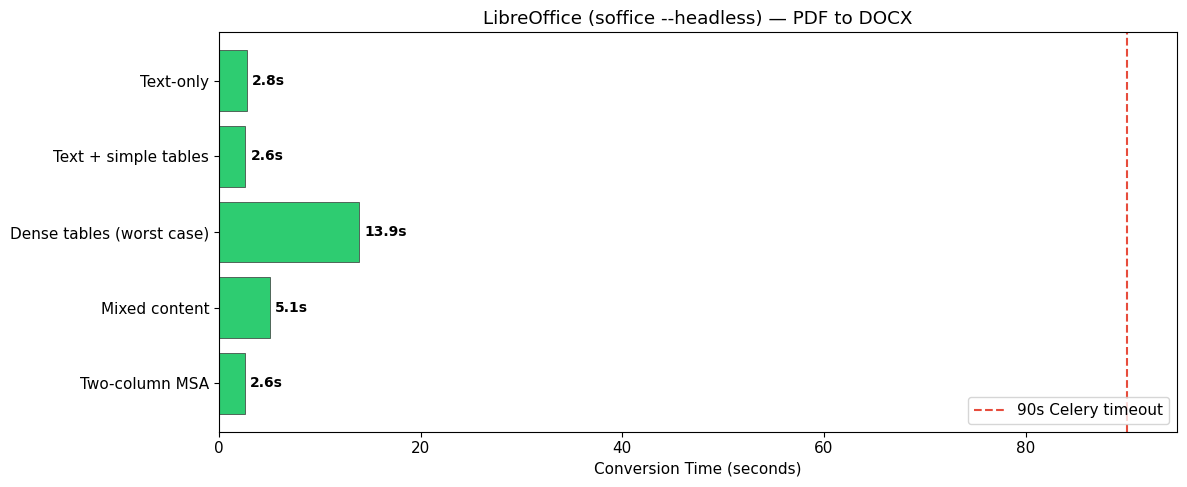

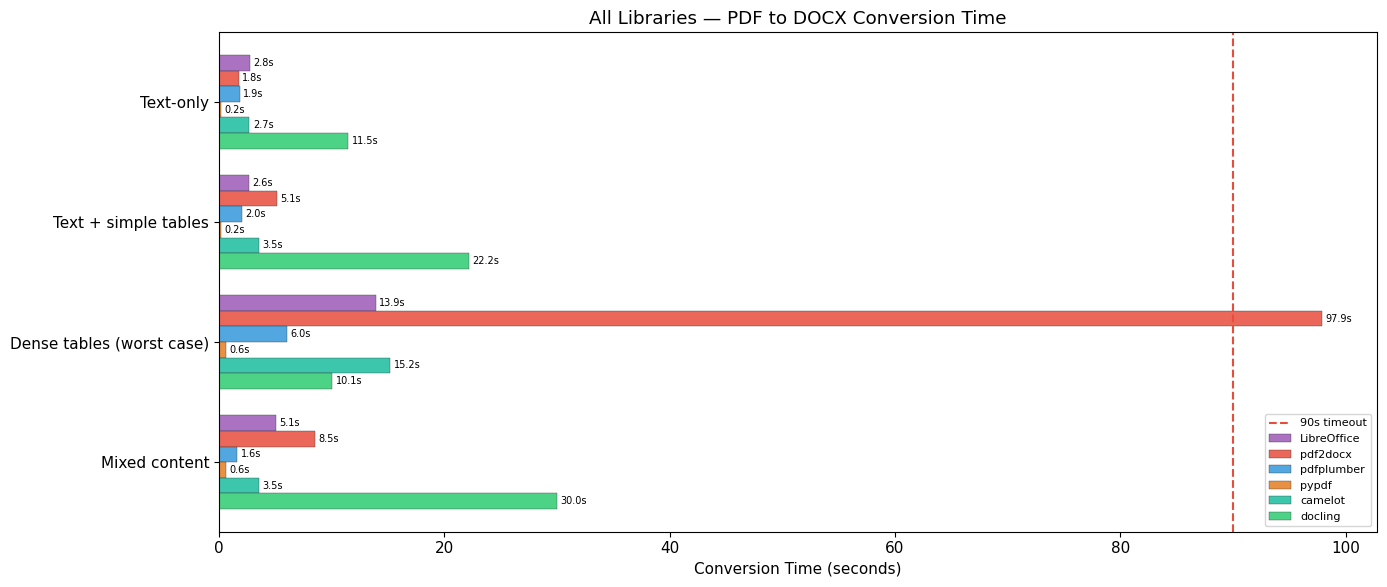


Charts saved to /tmp/libreoffice_bench/

Output files:
  all_libraries_comparison.png              82 KB
  dense_tables.docx                        454 KB
  dense_tables.pdf                       2,301 KB
  libreoffice_results.png                   62 KB
  mixed_content.docx                       159 KB
  mixed_content.pdf                        730 KB
  simple_tables.docx                       136 KB
  simple_tables.pdf                        593 KB
  text_only.docx                            72 KB
  text_only.pdf                            398 KB
  two_column_msa.docx                      188 KB
  two_column_msa.pdf                        64 KB


In [9]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts.")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})

    # Chart 1: LibreOffice results
    scenarios_plot = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors_chart = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(scenarios_plot, times, color=colors_chart, edgecolor="#333", linewidth=0.5)
    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title(f"LibreOffice (soffice --headless) — PDF to DOCX")
    ax.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(max(times) * 1.3, 95))
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "libreoffice_results.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # Chart 2: All libraries comparison (4 common scenarios)
    common = ["Text-only", "Text + simple tables", "Dense tables (worst case)", "Mixed content"]
    libs = {"LibreOffice": {r["scenario"]: r["total_s"] for r in results}}
    libs.update(other_results)
    
    lib_names = ["LibreOffice", "pdf2docx", "pdfplumber", "pypdf", "camelot", "docling"]
    colors_libs = ["#9b59b6", "#e74c3c", "#3498db", "#e67e22", "#1abc9c", "#2ecc71"]

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(common))
    width = 0.13
    
    for i, (lib, color) in enumerate(zip(lib_names, colors_libs)):
        vals = [libs[lib].get(s, 0) or 0 for s in common]
        offset = (i - len(lib_names)/2 + 0.5) * width
        bars = ax.barh(x + offset, vals, height=width, label=lib, color=color, alpha=0.85, edgecolor="#333", linewidth=0.3)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.1f}s", va="center", fontsize=7)

    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax.set_yticks(x)
    ax.set_yticklabels(common)
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title("All Libraries — PDF to DOCX Conversion Time")
    ax.legend(loc="lower right", fontsize=8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "all_libraries_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nCharts saved to {OUTPUT_DIR}/")

# File listing
print("\nOutput files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<35} {size_kb:>8,.0f} KB")

---
## Conclusion

### LibreOffice Key Properties

| Property | Value |
|----------|-------|
| License | MPL-2.0 (Mozilla Public License) |
| Approach | Native rendering engine (same as LibreOffice desktop) |
| Install size | ~200+ MB (full office suite) |
| System dependency | Requires `soffice` binary on the server |
| Python integration | subprocess call (`soffice --headless`) |
| Table detection | Native — uses PDF drawing commands to reconstruct tables |
| Image extraction | Native — preserves embedded images |
| Layout preservation | Good — multi-column, headers/footers, fonts |
| Two-column support | Yes — detects and converts column layouts |

### Tradeoffs

**Pros:**
- Highest fidelity of any option tested (same engine that renders PDFs in the desktop app)
- Handles tables, images, fonts, layout natively
- No Python PDF library dependencies
- MPL-2.0 licensed (permissive, compatible with commercial use)

**Cons:**
- Requires LibreOffice installed on the server (200+ MB)
- Subprocess call adds overhead vs. in-process Python
- No fine-grained control (can't adjust table detection sensitivity, etc.)
- Headless mode can occasionally hang on malformed PDFs (need timeout wrapper)
- Not a pip-installable library — DevOps/Docker setup required

### Deployment Considerations

```dockerfile
# Docker example
RUN apt-get update && apt-get install -y libreoffice-core libreoffice-writer
```

For Celery tasks, wrap in a subprocess with timeout:
```python
subprocess.run(
    ["soffice", "--headless", "--convert-to", "docx", "--outdir", out_dir, pdf_path],
    timeout=85,  # Leave 5s buffer for Celery's 90s timeout
)
```